In [ ]:
import numpy as np
import matplotlib.pyplot as plt

from tensorflow.keras.datasets import mnist
from tensorflow.keras.models import Model
from tensorflow.keras.layers import Input, Dense
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, classification_report

In [ ]:
(X_train, y_train), (X_test, y_test) = mnist.load_data()

print("Training images:", X_train.shape)
print("Testing images:", X_test.shape)

11490434/11490434 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
Training images: (60000, 28, 28)
Testing images: (10000, 28, 28)


In [ ]:
train_mask = (y_train == 0) | (y_train == 1)
test_mask = (y_test == 0) | (y_test == 1)

X_train_01 = X_train[train_mask]
y_train_01 = y_train[train_mask]

X_test_01 = X_test[test_mask]
y_test_01 = y_test[test_mask]

print("Training samples:", X_train_01.shape)
print("Testing samples:", X_test_01.shape)

Training samples: (12665, 28, 28)
Testing samples: (2115, 28, 28)


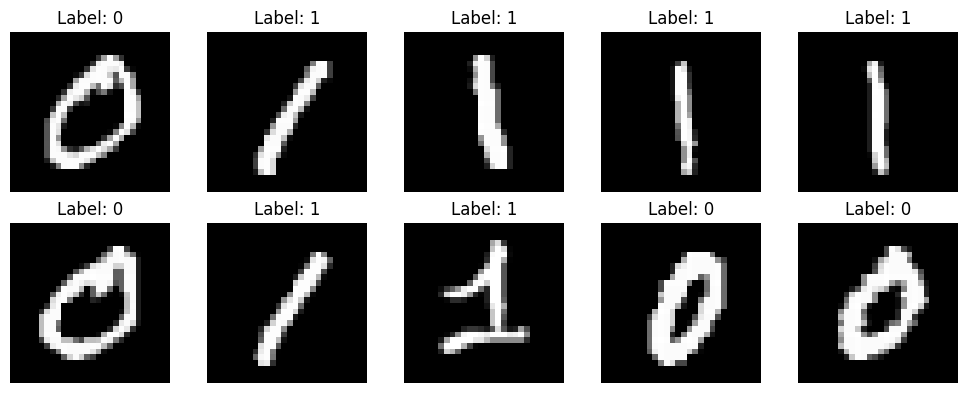

In [ ]:
plt.figure(figsize=(10, 4))

for i in range(10):
    plt.subplot(2, 5, i + 1)
    plt.imshow(X_train_01[i], cmap='gray')
    plt.title(f"Label: {y_train_01[i]}")
    plt.axis('off')

plt.tight_layout()
plt.show()

In [ ]:
X_train_scaled = X_train_01 / 255.0
X_test_scaled = X_test_01 / 255.0

X_train_flat = X_train_scaled.reshape(X_train_scaled.shape[0], -1)
X_test_flat = X_test_scaled.reshape(X_test_scaled.shape[0], -1)

print("Flattened training shape:", X_train_flat.shape)
print("Flattened testing shape:", X_test_flat.shape)

Flattened training shape: (12665, 784)
Flattened testing shape: (2115, 784)


In [ ]:
discriminative_model = LogisticRegression(max_iter=1000)

discriminative_model.fit(X_train_flat, y_train_01)

print("Discriminative model training completed.")

Discriminative model training completed.


In [ ]:
y_pred = discriminative_model.predict(X_test_flat)

print("First 20 actual labels:")
print(y_test_01[:20])

print("\nFirst 20 predicted labels:")
print(y_pred[:20])

First 20 actual labels:
[1 0 1 0 0 1 0 0 1 1 1 1 1 1 0 1 0 0 1 1]

First 20 predicted labels:
[1 0 1 0 0 1 0 0 1 1 1 1 1 1 0 1 0 0 1 1]


In [ ]:
accuracy = accuracy_score(y_test_01, y_pred)

print(f"Discriminative Model Accuracy: {accuracy * 100:.2f}%")

Discriminative Model Accuracy: 99.95%


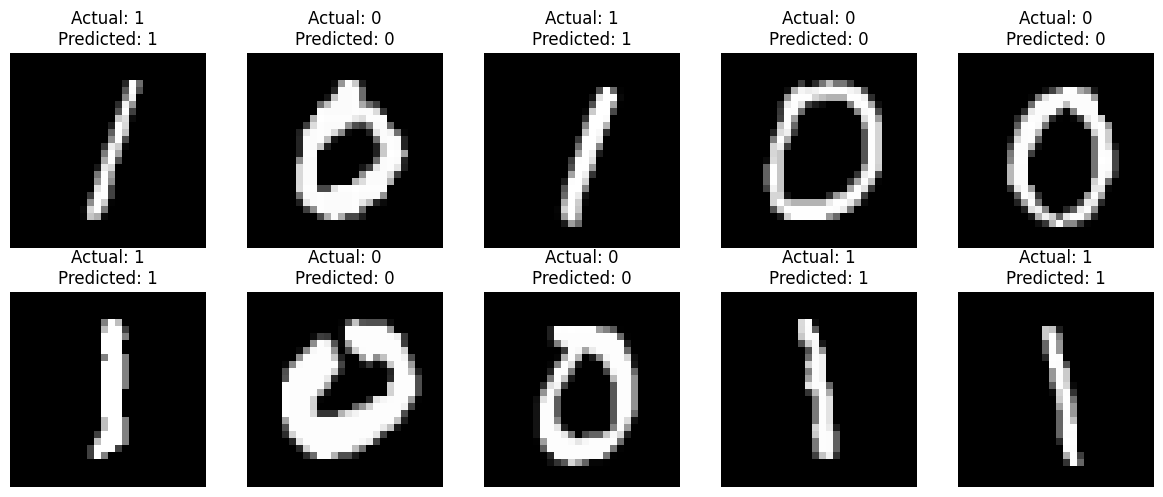

In [ ]:
plt.figure(figsize=(12, 5))

for i in range(10):
    plt.subplot(2, 5, i + 1)
    plt.imshow(X_test_01[i], cmap='gray')
    plt.title(f"Actual: {y_test_01[i]}\nPredicted: {y_pred[i]}")
    plt.axis('off')

plt.tight_layout()
plt.show()

In [ ]:
X_autoencoder = X_train_flat

print("Autoencoder input shape:", X_autoencoder.shape)

Autoencoder input shape: (12665, 784)


In [ ]:
input_img = Input(shape=(784,))

encoded = Dense(128, activation='relu')(input_img)
encoded = Dense(64, activation='relu')(encoded)
latent = Dense(16, activation='relu')(encoded)

decoded = Dense(64, activation='relu')(latent)
decoded = Dense(128, activation='relu')(decoded)
output_img = Dense(784, activation='sigmoid')(decoded)

autoencoder = Model(input_img, output_img)

autoencoder.compile(
    optimizer='adam',
    loss='binary_crossentropy'
)

autoencoder.summary()

Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer (InputLayer)        │ (None, 784)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 128)            │       100,480 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 16)             │         1,040 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 64)             │         1,088 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (None, 128)            │         8,320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_5 (Dense)                 │ (None, 784)            │       101,136 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 220,320 (860.62 KB)

 Trainable params: 220,320 (860.62 KB)

 Non-trainable params: 0 (0.00 B)

In [ ]:
history = autoencoder.fit(
    X_autoencoder,
    X_autoencoder,
    epochs=15,
    batch_size=128,
    validation_split=0.1,
    verbose=1
)

Epoch 1/15
90/90 ━━━━━━━━━━━━━━━━━━━━ 3s 9ms/step - loss: 0.2805 - val_loss: 0.1567
Epoch 2/15
90/90 ━━━━━━━━━━━━━━━━━━━━ 1s 7ms/step - loss: 0.1385 - val_loss: 0.1267
Epoch 3/15
90/90 ━━━━━━━━━━━━━━━━━━━━ 1s 8ms/step - loss: 0.1209 - val_loss: 0.1157
Epoch 4/15
90/90 ━━━━━━━━━━━━━━━━━━━━ 1s 7ms/step - loss: 0.1117 - val_loss: 0.1091
Epoch 5/15
90/90 ━━━━━━━━━━━━━━━━━━━━ 1s 7ms/step - loss: 0.1060 - val_loss: 0.1066
Epoch 6/15
90/90 ━━━━━━━━━━━━━━━━━━━━ 1s 7ms/step - loss: 0.1010 - val_loss: 0.0989
Epoch 7/15
90/90 ━━━━━━━━━━━━━━━━━━━━ 2s 13ms/step - loss: 0.0969 - val_loss: 0.0957
Epoch 8/15
90/90 ━━━━━━━━━━━━━━━━━━━━ 1s 8ms/step - loss: 0.0936 - val_loss: 0.0927
Epoch 9/15
90/90 ━━━━━━━━━━━━━━━━━━━━ 1s 7ms/step - loss: 0.0910 - val_loss: 0.0913
Epoch 10/15
90/90 ━━━━━━━━━━━━━━━━━━━━ 1s 7ms/step - loss: 0.0891 - val_loss: 0.0898
Epoch 11/15
90/90 ━━━━━━━━━━━━━━━━━━━━ 1s 7ms/step - loss: 0.0874 - val_loss: 0.0874
Epoch 12/15
90/90 ━━━━━━━━━━━━━━━━━━━━ 1s 7ms/step - loss: 0.0859 - val_l

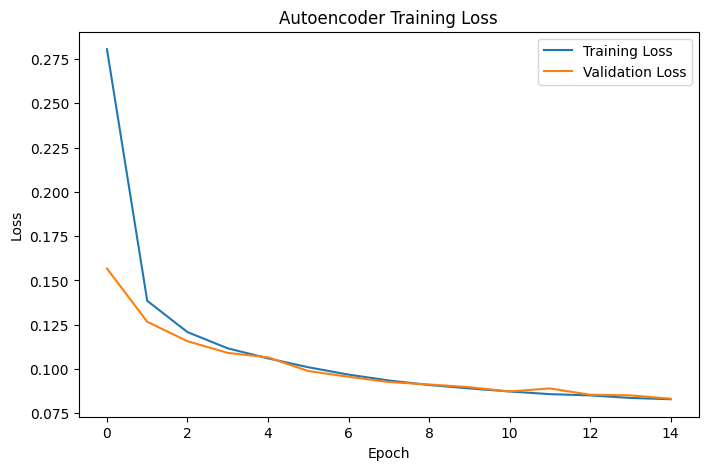

In [ ]:
plt.figure(figsize=(8, 5))

plt.plot(history.history['loss'], label='Training Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')

plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.title('Autoencoder Training Loss')
plt.legend()
plt.show()

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 63ms/step


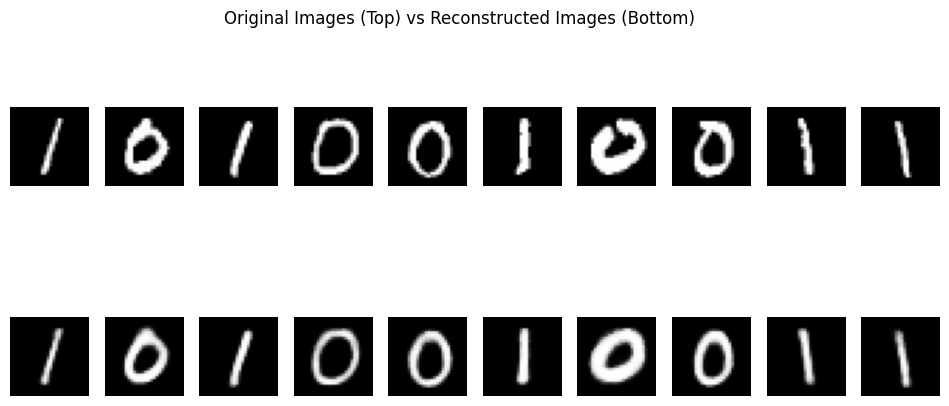

In [ ]:
reconstructed = autoencoder.predict(X_test_flat[:10])

plt.figure(figsize=(12, 5))

for i in range(10):
    plt.subplot(2, 10, i + 1)
    plt.imshow(X_test_flat[i].reshape(28, 28), cmap='gray')
    plt.axis('off')

    plt.subplot(2, 10, i + 11)
    plt.imshow(reconstructed[i].reshape(28, 28), cmap='gray')
    plt.axis('off')

plt.suptitle("Original Images (Top) vs Reconstructed Images (Bottom)")
plt.show()

In [ ]:
encoder = Model(input_img, latent)

latent_input = Input(shape=(16,))
decoder_layer1 = autoencoder.layers[-3](latent_input)
decoder_layer2 = autoencoder.layers[-2](decoder_layer1)
decoder_output = autoencoder.layers[-1](decoder_layer2)

decoder = Model(latent_input, decoder_output)

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 76ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 84ms/step


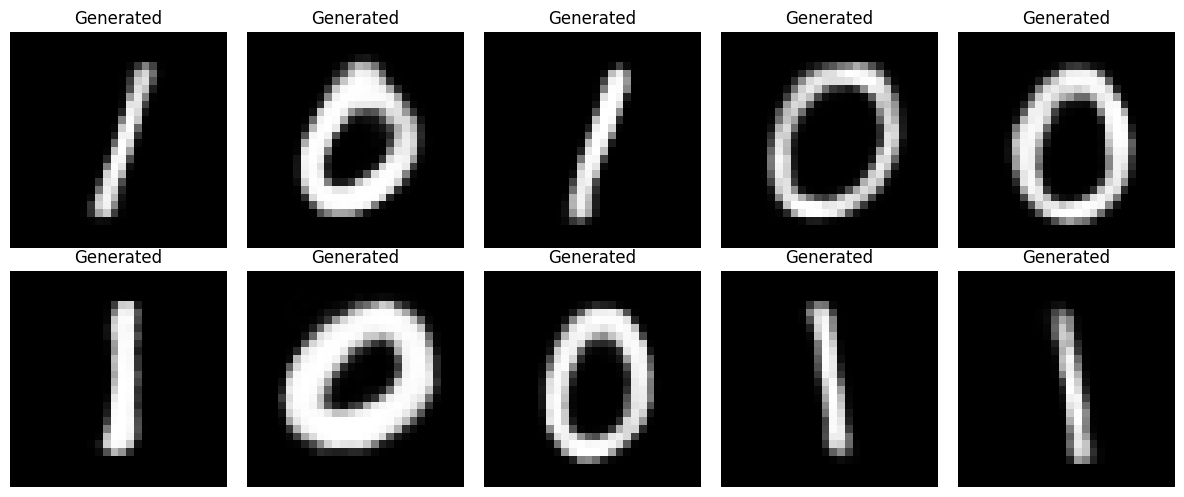

In [ ]:
sample_images = X_test_flat[:10]

latent_vectors = encoder.predict(sample_images)

noise = np.random.normal(0, 0.5, latent_vectors.shape)

new_latent_vectors = latent_vectors + noise

generated_images = decoder.predict(new_latent_vectors)

plt.figure(figsize=(12, 5))

for i in range(10):
    plt.subplot(2, 5, i + 1)
    plt.imshow(generated_images[i].reshape(28, 28), cmap='gray')
    plt.title("Generated")
    plt.axis('off')

plt.tight_layout()
plt.show()

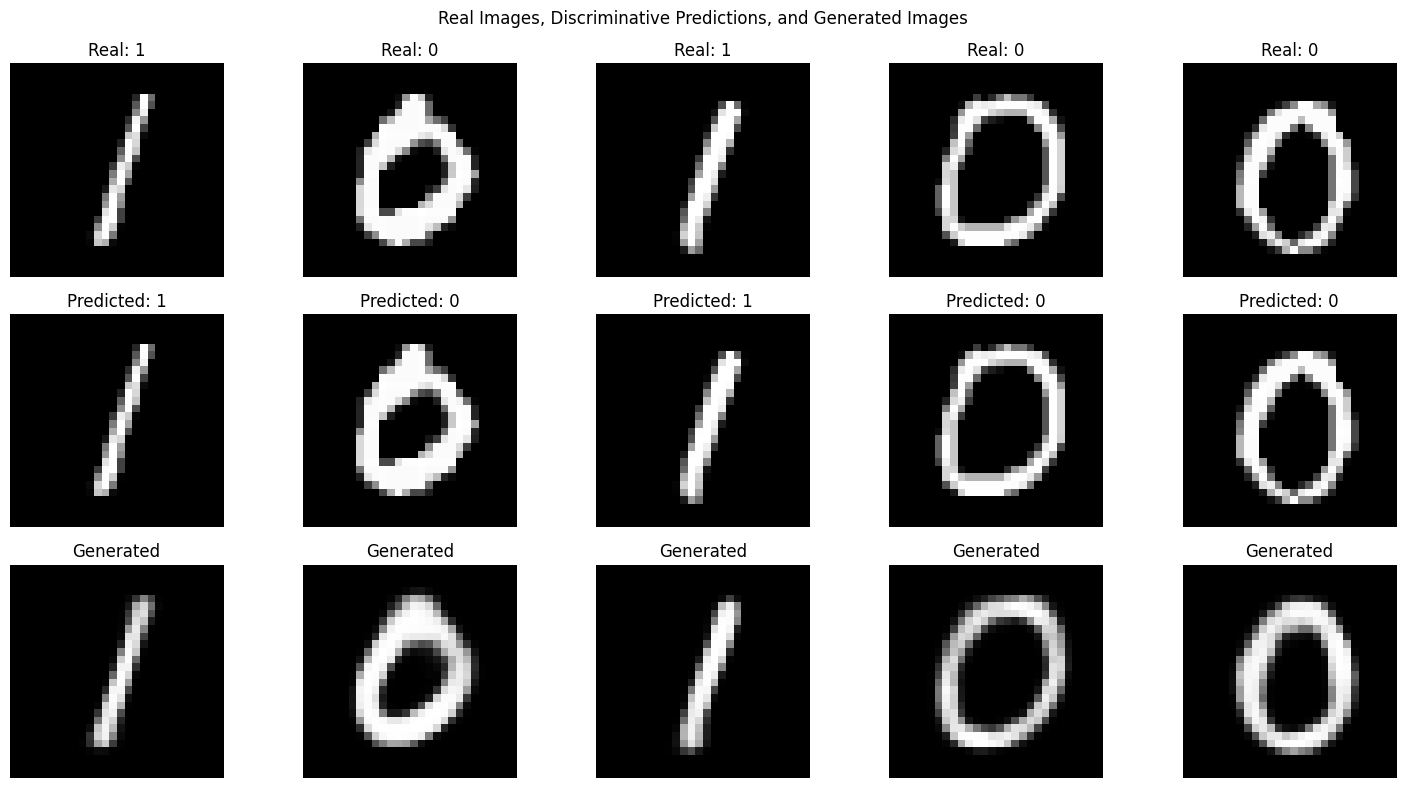

In [ ]:
plt.figure(figsize=(15, 8))

for i in range(5):

    plt.subplot(3, 5, i + 1)
    plt.imshow(X_test_01[i], cmap='gray')
    plt.title(f"Real: {y_test_01[i]}")
    plt.axis('off')

    plt.subplot(3, 5, i + 6)
    plt.imshow(X_test_01[i], cmap='gray')
    plt.title(f"Predicted: {y_pred[i]}")
    plt.axis('off')

    plt.subplot(3, 5, i + 11)
    plt.imshow(generated_images[i].reshape(28, 28), cmap='gray')
    plt.title("Generated")
    plt.axis('off')

plt.suptitle("Real Images, Discriminative Predictions, and Generated Images")
plt.tight_layout()
plt.show()

In [ ]:
The discriminative model learned the differences between the handwritten digits 0 and 1 and used them to predict the correct digit.
The generative Autoencoder learned the common patterns and shapes of the digit images.
It used this knowledge to reconstruct and create similar digit images.
The main difference is that the discriminative model focuses on predicting the correct class,
while the generative model focuses on learning how the data looks and is structured.
